# Notebook 02: Correcting the Bias

This notebook runs the end-to-end **bias correction workflow** to transform IMERG precipitation into bias-corrected products for a **user-selected month and dekad**. The workflow is designed to be reproducible across environments (Colab or local Jupyter) by centralizing all runtime settings in `config.yml` at the project root.

**What this notebook does**
- **Linear Scaling (LS):** adjusts mean bias.
- **Empirical Quantile Mapping (EQM) + Gamma fitting:** aligns distributions.
- **GPD tail adjustment:** improves representation of extremes.
- **Optional Deep Learning (DL) refinement:** learns residual structure from **LSEQM → CPC** to further refine the corrected product.

**Reproducibility note**
- Colab-specific steps (Drive mounting, `pip install`) are explicitly marked.  
- Outside Colab, you can skip those sections and keep the same workflow logic unchanged.
- To port the workflow to a new environment, update only `config.yml` (paths + runtime switches).

---


::: {.callout-note title="What you'll do in this notebook"}
- Run the full **LS → LSEQM → LSEQM+DL** correction chain for one (month, dekad).
- Train the CNN refinement model and save it to disk.
- Save the three corrected NetCDFs that the next notebooks use.

**Runtime**: about **3 to 5 minutes** on Colab CPU for one Bali dekad. The batch cell at the bottom processes all 36 dekads in about **15 minutes**.

**Concept references** ([docs site](https://bennyistanto.github.io/hybrid-bias-correction)):
- [Linear Scaling](https://bennyistanto.github.io/hybrid-bias-correction/methodology/linear-scaling.html) - mean correction
- [EQM + Gamma fit](https://bennyistanto.github.io/hybrid-bias-correction/methodology/eqm.html) - distribution correction
- [GPD tail](https://bennyistanto.github.io/hybrid-bias-correction/methodology/gpd-tail.html) - extremes
- [CNN refinement](https://bennyistanto.github.io/hybrid-bias-correction/methodology/cnn-refinement.html) - the deep-learning layer
- [Confidence mask](https://bennyistanto.github.io/hybrid-bias-correction/methodology/confidence-mask.html) and [blending](https://bennyistanto.github.io/hybrid-bias-correction/methodology/blending.html) - how DL is gated
:::


## 1 Connect Google Drive (Colab only)

This section is only required when running in **Google Colab** and your project/data are stored in Google Drive.

- Mounting Drive makes your repository and datasets accessible under `/content/drive`.
- If you run this notebook locally (Jupyter / VS Code), **skip this section**.

**Expected structure (Drive)**
After mounting, your project root should contain:
- `notebooks/`
- `src/`
- `config.yml` (or `config.yaml`)

Proceed to the code cell below to mount Drive.

In [3]:
from google.colab import drive
import os

# Check if the drive is mounted
if os.path.exists('/content/drive'):
    # Try to unmount
    try:
        drive.flush_and_unmount()
        print("Successfully unmounted")
    except:
        print("Unmount failed, the drive might not be mounted or busy")

# Mount the drive
drive.mount('/content/drive')

Mounted at /content/drive


**Troubleshooting:**  
- If Colab becomes disconnected, Reconnect the runtime and rerun the mounting cell.
- If we receive an error such as `Mountpoint must not already contain files`, delete all the sub-folders under "/content/drive" from the Files panel before retrying. We need to delete these one by one starting from the innermost folders, until the last "drive" folder is deleted.


## 2 Install packages (only if needed)

In most cases, **Google Colab already includes the packages required** for this workflow. The most common missing dependency is **`netCDF4`** (NetCDF I/O support).

### Check what is already installed (Colab)
Before installing anything, you can inspect the current environment by running `!pip list`.

- If all required packages are present and only `netCDF4` is missing, install **only `netCDF4`**.
- If other required packages are missing from `!pip list`, install them **together with** `netCDF4` in the code cell below.

### Local Jupyter note
If you are running in a **local environment** (Jupyter / VS Code), assume all dependencies were installed when preparing the environment following the **main repository README**. In that case, you can skip this section.

Proceed to the code cell below only when installation is necessary.

In [4]:
# In Google Colab, almost all packages already available, except netCDF4
!pip install netCDF4

## 3 Executing the Bias Correction Workflow

In this section, we will execute the full bias correction process. The process involves:

- **Adjusting Values (Linear Scaling, LS):**
  Correct the mean bias by scaling satellite-based precipitation using the ratio of observed to satellite means. ([why per-dekad?](https://bennyistanto.github.io/hybrid-bias-correction/get-started/data-model.html#dekad-temporal-convention))

- **Aligning Distributions (EQM and Gamma Quantile Mapping):**
  Match the cumulative distribution functions of the satellite data to that of the observed data, with a parametric Gamma fit to the body. ([EQM details](https://bennyistanto.github.io/hybrid-bias-correction/methodology/eqm.html))

- **Preserving Extremes (GPD Tail Adjustment):**
  Replace the empirical CDF above the 80th percentile with a Generalized Pareto Distribution to handle extremes that EQM under-samples. ([GPD tail](https://bennyistanto.github.io/hybrid-bias-correction/methodology/gpd-tail.html))

- **Spatial Refinement (CNN + station-density blending):**
  A lightweight CNN learns the residual spatial pattern of LSEQM, blended back with a confidence weight driven by gauge density. ([CNN](https://bennyistanto.github.io/hybrid-bias-correction/methodology/cnn-refinement.html), [confidence mask](https://bennyistanto.github.io/hybrid-bias-correction/methodology/confidence-mask.html), [blending](https://bennyistanto.github.io/hybrid-bias-correction/methodology/blending.html))


### Step 1: Setup Environment

This section prepares the notebook runtime so the project modules can be imported consistently.

The setup typically:
- ensures the **project root** is on the Python path (so `import src...` works),
- loads the central configuration file (`config.yml` / `config.yaml`) from the project root, and
- prints key paths to confirm the run is using the intended inputs/outputs.

**Reproducibility principle**
All operational settings (paths, runtime switches, output directories) should come from the configuration file. Avoid editing paths inside notebook cells unless you are deliberately testing an alternative setup.

Proceed to the code cell below to initialize the environment and configuration.

In [5]:
# Setup: Add project root to Python path
import sys
import os
import importlib
import logging

# Configure logging
logging.basicConfig(level=logging.INFO)

# ---------------------------------------------------------------------------
# Windows DLL fix for conda environments
# ---------------------------------------------------------------------------
if sys.platform == 'win32':
    _conda_prefix = os.environ.get('CONDA_PREFIX') or sys.prefix
    _dll_dirs = [
        os.path.join(_conda_prefix, 'Library', 'bin'),
        os.path.join(_conda_prefix, 'Library', 'lib'),
        os.path.join(_conda_prefix, 'Library', 'mingw-w64', 'bin'),
        os.path.join(_conda_prefix, 'bin'),
        _conda_prefix,
    ]
    for _d in _dll_dirs:
        if os.path.isdir(_d):
            try:
                os.add_dll_directory(_d)
            except OSError:
                pass
            if _d not in os.environ.get('PATH', ''):
                os.environ['PATH'] = _d + os.pathsep + os.environ.get('PATH', '')
    del _conda_prefix, _dll_dirs, _d

# ---------------------------------------------------------------------------
# Project root — hardcoded for local Jupyter.
# Change this path to match your local project location.
# ---------------------------------------------------------------------------

# ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
ROOT = '/content/drive/MyDrive/hybrid-bias-correction'
assert os.path.isfile(os.path.join(ROOT, 'src', 'config.py')), f"Not found: {ROOT}"

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
for m in [k for k in sys.modules if k.startswith('src')]:
    del sys.modules[m]

# Initialize configuration from config.yml
# (setup_logging() is called automatically when src.config is imported)
import src.config as _cfg
importlib.reload(_cfg)
# ===========================================================================
# AOI config selector
#   'config.yml'      -> full Indonesia (Zenodo input/output bundle)
#   'config_bali.yml' -> Bali example (ships with the repo, ~11 MB)
# Edit this single line to switch the entire pipeline between the two.
# ===========================================================================
CONFIG_FILE = 'config_bali.yml'

_cfg.initialize_config(os.path.join(ROOT, CONFIG_FILE))

# Verify configuration
from src import config
print("Configuration loaded successfully:")
print(f"  Main directory  : {config.main_dir}")
print(f"  Input directory : {config.input_dir}")
print(f"  Output directory: {config.output_dir}")
print(f"  IMERGL file     : {config.imergl_file}")
print(f"  CPC file        : {config.cpc_file}")
print(f"  Mask file       : {config.mask_file}")
print(f"  NetCDF engine   : {config.NETCDF_ENGINE}")
print(f"  Interactive     : {config.INTERACTIVE}")

2026-05-22 00:50:18,337 - INFO - NumExpr defaulting to 2 threads.
2026-05-22 00:50:24,964 - INFO - Loaded configuration from /content/drive/MyDrive/hybrid-bias-correction/config_bali.yml
2026-05-22 00:50:24,969 - INFO - Configured main_dir '/content/hybrid-bias-correction' does not exist on this system. Using auto-detected project root: /content/drive/MyDrive/hybrid-bias-correction
2026-05-22 00:50:25,551 - INFO - Configuration initialized successfully.
2026-05-22 00:50:25,553 - INFO -   Main directory: /content/drive/MyDrive/hybrid-bias-correction
2026-05-22 00:50:25,554 - INFO -   Input directory: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali
2026-05-22 00:50:25,558 - INFO -   Output directory: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output
2026-05-22 00:50:25,560 - INFO -   Interactive mode: False
Configuration loaded successfully:
  Main directory  : /content/drive/MyDrive/hybrid-bias-correction
  Input directory : /content/drive/MyDrive/hy

### Step 2: Gather User Inputs

This cell prompts the user to input the month (1–12) and dekad (1, 2, or 3). Input validation is performed to ensure only valid values are accepted. For the third dekad, note that the maximum day of the month will be determined in a later cell.

In [6]:
# Import Library
import logging

# Configure logging
logging.basicConfig(level=logging.INFO)

# Prompt user for month and dekad
month_input = input("Enter the month (1–12): ").strip()
dekad_input = input("Enter the dekad (1, 2, or 3): ").strip()

try:
    month = int(month_input)
    if not (1 <= month <= 12):
        raise ValueError
except ValueError:
    raise SystemExit("Invalid month. Please provide a number from 1 to 12.")

try:
    dekad = int(dekad_input)
    if dekad not in [1, 2, 3]:
        raise ValueError
except ValueError:
    raise SystemExit("Invalid dekad. Must be 1, 2, or 3.")

logging.info("User selected: month=%s, dekad=%s", month, dekad)

# Format the month as a two-digit string
month_str = f"{month:02d}"

# Set the dekad start and default dekad_str; end day for dekad 3 will be set later
if dekad == 1:
    dekad_str = "01"
    dekad_start, dekad_end = 1, 10
elif dekad == 2:
    dekad_str = "11"
    dekad_start, dekad_end = 11, 20
else:
    dekad_str = "21"
    dekad_start = 21  # dekad_end will be updated after loading dataset


Enter the month (1–12): 1
Enter the dekad (1, 2, or 3): 1
2026-05-22 00:50:35,268 - INFO - User selected: month=1, dekad=1


### Step 3: Load Datasets

In this cell, we import the necessary libraries and load both the IMERG and CPC datasets using the file paths defined in `config.py`.

In [7]:
# Import Library
import xarray as xr
from src import config
from src.utility import apply_land_sea_mask

# Use auto-detected engine
_engine = config.NETCDF_ENGINE

logging.info("Loading IMERG dataset from: %s (engine=%s)", config.imergl_file, _engine)
imerg_ds = xr.open_dataset(config.imergl_file, decode_times=True, engine=_engine)
logging.info("IMERG dataset loaded. Time range: %s to %s",
             imerg_ds.time.values[0], imerg_ds.time.values[-1])

logging.info("Loading CPC dataset from: %s (engine=%s)", config.cpc_file, _engine)
cpc_ds = xr.open_dataset(config.cpc_file, decode_times=True, engine=_engine)
logging.info("CPC dataset loaded. Time range: %s to %s",
             cpc_ds.time.values[0], cpc_ds.time.values[-1])

# Load native 0.5° CPC for BCSD parameter fitting (Option B).
# This file was produced by Notebook 01 (Step 2b + 3b): gap-filled at native
# 0.5° resolution, NOT regridded to 0.1°.  lseqm() fits CPC distribution
# parameters on this grid and bilinearly interpolates them to the IMERG 0.1°
# grid, eliminating the 5×5 block boundary artefact.
import os
if hasattr(config, 'cpc_native_file') and os.path.isfile(config.cpc_native_file):
    logging.info("Loading native 0.5° CPC from: %s", config.cpc_native_file)
    cpc_ds_native = xr.open_dataset(config.cpc_native_file, decode_times=True, engine=_engine)
    logging.info("Native CPC loaded: %d lat x %d lon (%.2f deg resolution)",
                 len(cpc_ds_native.lat), len(cpc_ds_native.lon),
                 abs(float(cpc_ds_native.lat[1] - cpc_ds_native.lat[0])))
else:
    logging.warning("Native 0.5 deg CPC file not found at %s; "
                    "falling back to cpc_ds (block artefacts may appear)",
                    getattr(config, 'cpc_native_file', 'NOT CONFIGURED'))
    cpc_ds_native = None

# Apply land-sea mask ONCE at data loading to set ocean pixels to NaN.
# This prevents ocean zeros from contaminating statistical calculations downstream.
# The mask is cached internally, so subsequent calls are fast.
logging.info("Applying land-sea mask to both datasets...")
imerg_ds[config.IMERG_PRECIP_VAR] = apply_land_sea_mask(
    imerg_ds[config.IMERG_PRECIP_VAR], config.mask_file
)
cpc_ds[config.CPC_PRECIP_VAR] = apply_land_sea_mask(
    cpc_ds[config.CPC_PRECIP_VAR], config.mask_file
)
logging.info("Land-sea mask applied. Ocean pixels are now NaN.")

2026-05-22 00:50:38,886 - INFO - Loading IMERG dataset from: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/bali_imergl.nc4 (engine=netcdf4)
2026-05-22 00:50:41,138 - INFO - IMERG dataset loaded. Time range: 2001-01-01T00:00:00.000000000 to 2025-12-31T00:00:00.000000000
2026-05-22 00:50:41,139 - INFO - Loading CPC dataset from: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/bali_cpcuni.nc4 (engine=netcdf4)
2026-05-22 00:50:42,645 - INFO - CPC dataset loaded. Time range: 2001-01-01T00:00:00.000000000 to 2025-12-31T00:00:00.000000000
2026-05-22 00:50:42,648 - INFO - Loading native 0.5° CPC from: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/bali_cpcuni_native05.nc4
2026-05-22 00:50:43,922 - INFO - Native CPC loaded: 4 lat x 6 lon (0.50 deg resolution)
2026-05-22 00:50:43,923 - INFO - Applying land-sea mask to both datasets...
2026-05-22 00:50:43,927 - INFO - Loading land-sea mask from /content/drive/MyDrive/hybrid-bias-correction/data/e

After loading, we can preview a summary and a quick plot of the raw IMERG data to make sure it loaded correctly.

::: {.callout-tip title="What you should see"}
For Bali in January, raw IMERG-L typically shows daily wet-day means in the **2 to 15 mm** range with localised peaks of 30 to 60 mm. The map should be coloured everywhere over land - the entire Bali subset is gauged, so no ocean-NaN patches over land should appear. If you see a uniform-coloured map or NaN-everywhere, the wrong input file or AOI is most likely the cause.
:::


IMERG Data Summary:
<xarray.Dataset> Size: 5MB
Dimensions:        (time: 9131, lat: 9, lon: 14)
Coordinates:
  * time           (time) datetime64[ns] 73kB 2001-01-01 ... 2025-12-31
  * lat            (lat) float32 36B -8.85 -8.75 -8.65 ... -8.25 -8.15 -8.05
  * lon            (lon) float32 56B 114.4 114.6 114.7 ... 115.6 115.7 115.8
Data variables:
    precipitation  (time, lat, lon) float32 5MB nan nan nan nan ... nan nan nan
Attributes:
    Conventions:  CF-1.8
    title:        IMERG Late Run daily precipitation subset for AOI


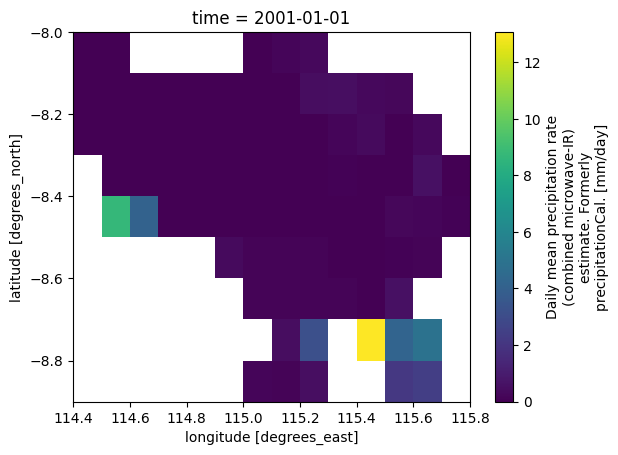

In [8]:
# Preview a snapshot of the raw IMERG dataset
print("IMERG Data Summary:")
print(imerg_ds)
imerg_ds[config.IMERG_PRECIP_VAR].isel(time=0).plot(cmap='viridis')

CPC Data Summary:
<xarray.Dataset> Size: 5MB
Dimensions:  (time: 9131, lat: 9, lon: 14)
Coordinates:
  * time     (time) datetime64[ns] 73kB 2001-01-01 2001-01-02 ... 2025-12-31
  * lat      (lat) float32 36B -8.85 -8.75 -8.65 -8.55 ... -8.25 -8.15 -8.05
  * lon      (lon) float32 56B 114.4 114.6 114.7 114.8 ... 115.6 115.7 115.8
Data variables:
    precip   (time, lat, lon) float32 5MB nan nan nan nan ... nan nan nan nan
Attributes:
    Conventions:  CF-1.8
    title:        CPC Unified daily precipitation (0.1 deg, AOI clipped)


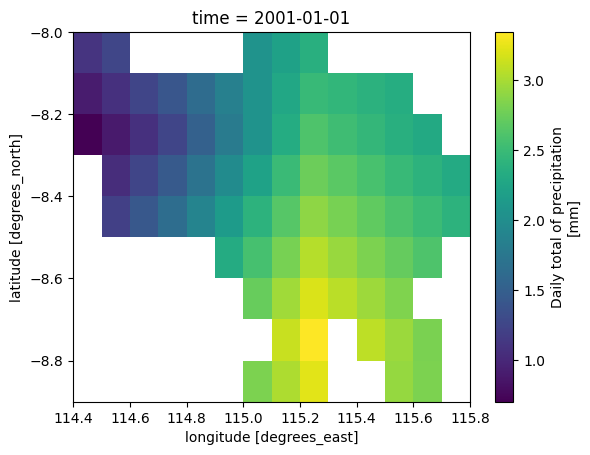

In [9]:
# Preview a snapshot of the raw CPC dataset
print("CPC Data Summary:")
print(cpc_ds)
cpc_ds[config.CPC_PRECIP_VAR].isel(time=0).plot(cmap='viridis')

### Step 4: Determine Maximum Day for Dekad 3

If the selected dekad is 3, we need to determine the maximum day of the month (to account for leap years). This cell imports and uses the `get_max_day_in_month` function from the `io` module to set `dekad_end` accordingly.

In [10]:
from src.io import get_max_day_in_month

if dekad == 3:
    dekad_end = get_max_day_in_month(imerg_ds, month)

logging.info("Using month=%s, dekad=%s (day-range: %s – %s)", month, dekad, dekad_start, dekad_end)

2026-05-22 00:51:19,798 - INFO - Using month=1, dekad=1 (day-range: 1 – 10)


### Step 5: Align Datasets

Next, we load the land-sea mask from the mask file defined in `config.py` and align the CPC dataset with the IMERG dataset. This is done using the `reindex_and_align_with_monotonicity` function from `utility.py`.

In [11]:
from src.utility import load_mask, reindex_and_align_with_monotonicity

# Load the land-sea mask (cached — efficient even if called multiple times)
land_sea_mask = load_mask(config.mask_file)

# Align CPC dataset with IMERG dataset (temporal and spatial alignment)
cpc_ds_aligned, _ = reindex_and_align_with_monotonicity(imerg_ds, cpc_ds, land_sea_mask)
logging.info("Datasets aligned successfully.")

2026-05-22 00:51:22,535 - INFO - Datasets aligned successfully.


### Step 6: Aggregate Multi-Year Dekad Data

We now aggregate the IMERG and CPC datasets across all years for the specified dekad. This uses the `aggregate_data_across_years` function from the `io` module. The aggregated data shapes are then logged.

In [12]:
from src.io import aggregate_data_across_years

# Aggregate datasets across all years for the specified dekad.
# IMPORTANT: Use cpc_ds_aligned (from Step 5), not the original cpc_ds.
# The original CPC dataset has a different native grid than IMERG.
# After reindex_and_align_with_monotonicity(), cpc_ds_aligned shares
# IMERG's exact lat/lon coordinates, so the inner join inside
# aggregate_data_across_years() will find matching coordinates.
imerg_dekad_data, cpc_dekad_data = aggregate_data_across_years(
    imerg_ds, cpc_ds_aligned, month, dekad_start, dekad_end
)
logging.info("Aggregated IMERG shape: %s", imerg_dekad_data.shape)
logging.info("Aggregated CPC shape: %s", cpc_dekad_data.shape)

2026-05-22 00:52:20,528 - INFO - Aligning IMERG and CPC datasets...
2026-05-22 00:52:20,545 - INFO - After alignment: IMERG has 9131 time steps, CPC has 9131 time steps
2026-05-22 00:52:20,546 - INFO - Creating time-based masks...
2026-05-22 00:52:20,574 - INFO - Applying time masks...
2026-05-22 00:52:20,609 - INFO - Aggregated IMERG shape: (250, 9, 14)
2026-05-22 00:52:20,612 - INFO - Aggregated CPC shape: (250, 9, 14)


We can preview the aggregated data summary and plot an example slice to validate the aggregation.

::: {.callout-tip title="What you should see"}
The aggregated dekad array stacks every year's same-window days into one block. For Bali, dekad 1 of January over ~25 years gives roughly **~250 daily samples per pixel** - the per-pixel Gamma + GPD fits below need this much data to be stable. The example map should look like a smoother version of a single-day field (lots of co-located heavy days averaged out).
:::


Aggregated IMERG Data Summary:
<xarray.DataArray 'precipitation' (time: 250, lat: 9, lon: 14)> Size: 126kB
array([[[           nan,            nan,            nan, ...,
         2.11500001e+00, 2.39499974e+00,            nan],
        [           nan,            nan,            nan, ...,
         4.16500092e+00, 4.92000103e+00,            nan],
        [           nan,            nan,            nan, ...,
         5.39999962e-01,            nan,            nan],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 2.59999990e-01,            nan],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         2.34999999e-01,            nan,            nan],
        [0.00000000e+00, 0.00000000e+00,            nan, ...,
                    nan,            nan,            nan]],

       [[           nan,            nan,            nan, ...,
         1.55000001e-01, 2.49999985e-02,            nan],
        [           nan,            na

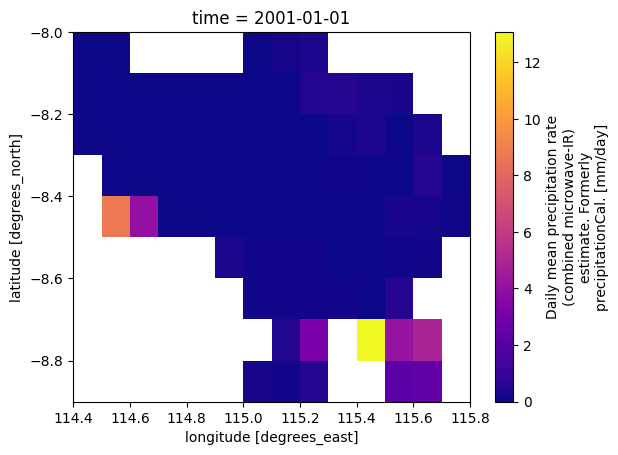

In [13]:
# Preview the aggregated dekad data for IMERG
print("Aggregated IMERG Data Summary:")
print(imerg_dekad_data)
imerg_dekad_data.isel(time=0).plot(cmap='plasma')


### Step 7: Run LSEQM Bias Correction

In this cell, we run the physical-statistical bias-correction pipeline: Linear Scaling followed by Empirical Quantile Mapping with a GPD tail. This is Step 1 of the two-step workflow. ([full theory](https://bennyistanto.github.io/hybrid-bias-correction/methodology/eqm.html#why-a-gamma-body-gpd-tail))

The `lseqm()` function returns both the LSEQM-corrected result and the aggregated CPC dekad data; the CPC array is the training target for the DL refinement in Step 8.

Run the cell below to fit the per-pixel Gamma + GPD parameters on the aggregated dekad data and apply LS + EQM + GPD. On Bali this takes about **30 to 60 seconds** on a Colab CPU.

::: {.callout-tip title="What you should see"}
You'll see one log line per pixel batch (`Processed N / 126 pixels`) and a final shape print. The returned `lseqm_corrected` array should have **non-negative values everywhere** and a daily maximum roughly between **50 and 150 mm/day** - close to the CPC reference range rather than IMERG-L's somewhat lower tail. The aggregated CPC array (second return value) is the target the CNN will train against in Step 8.
:::


In [14]:
from src.bias_correction import lseqm

logging.info("Running LSEQM bias correction (LS + EQM + GPD)...")

# IMPORTANT: Use cpc_ds_aligned (from Step 5), not the original cpc_ds.
# lseqm() internally calls aggregate_data_across_years(), which uses
# xr.align(join="inner"). This requires that IMERG and CPC share the
# same spatial grid — which is only true after alignment in Step 5.
#
# cpc_native_ds=cpc_ds_native passes the original 0.5° CPC so that
# distribution parameters (gamma, GPD) are fitted at native CPC resolution
# and bilinearly interpolated to the 0.1° IMERG grid. This eliminates
# the 0.5° block boundary artefact (BCSD principle, Wood et al. 2004).
lseqm_result, cpc_dekad_data = lseqm(
    imerg_ds, cpc_ds_aligned, month, dekad_start, dekad_end,
    month_str=month_str,
    dekad_str=dekad_str,
    ls_corrected_precip_path=config.ls_corrected_precip_path,
    lseqm_corrected_precip_path=config.lseqm_corrected_precip_path,
    cpc_native_ds=cpc_ds_native
)
logging.info("LSEQM bias correction completed successfully.")

2026-05-22 00:52:34,024 - INFO - Running LSEQM bias correction (LS + EQM + GPD)...
2026-05-22 00:52:34,032 - INFO - Aligning IMERG and CPC datasets...
2026-05-22 00:52:34,039 - INFO - After alignment: IMERG has 9131 time steps, CPC has 9131 time steps
2026-05-22 00:52:34,041 - INFO - Creating time-based masks...
2026-05-22 00:52:34,055 - INFO - Applying time masks...
2026-05-22 00:52:34,069 - INFO - IMERG dekad data shape: (250, 9, 14)
2026-05-22 00:52:34,070 - INFO - CPC dekad data shape: (250, 9, 14)
2026-05-22 00:52:34,075 - INFO - Using native-resolution CPC parameter fitting (BCSD principle)...
2026-05-22 00:52:34,113 - INFO - CPC native dekad data: (250, 4, 6) (lat -9.25–-7.75, lon 113.75–116.25)
2026-05-22 00:52:41,637 - INFO -   Native CPC fitting: row 4/4 (100%) | 24 fitted, 0 skipped | elapsed 8s, ETA 0s
2026-05-22 00:52:41,640 - INFO - Fitted CPC params on native grid: 24/24 cells
2026-05-22 00:52:41,736 - INFO - Interpolated CPC params to IMERG grid: 126/126 valid pixels
20

### Step 8: Train the Deep Learning Model on LSEQM -> CPC

In this cell, we train the DL model using the **LSEQM-corrected data** as input and **CPC** as the target. This is the key difference from the original workflow: the model learns what LSEQM missed (spatial residuals, extreme refinement) rather than the full IMERG -> CPC mapping. This avoids the train-vs-inference domain shift. ([architecture](https://bennyistanto.github.io/hybrid-bias-correction/methodology/cnn-refinement.html))

::: {.callout-note title="Reproducibility of the DL stage"}
The CNN's weight initialisation, dropout masks, and validation-split shuffle are all stochastic. To make runs reproducible, the framework **seeds them by default** (`deep_learning.random_seed: 0` in `config.yml`). With the seed set, two runs of this notebook on the same input produce a **bit-identical** `.keras` model and corrected output on CPU (the LS and LSEQM stages were already deterministic).

You will see a log line at training time confirming the mode:
`DL training RNGs seeded with 0 (reproducible).`

To restore the original stochastic behaviour (a different model on every run), set `random_seed: null` in your config. ([training entry point](https://bennyistanto.github.io/hybrid-bias-correction/technical/api-reference/deep_learning.html))

*Note*: full bit-for-bit reproducibility on a **GPU** additionally requires `TF_DETERMINISTIC_OPS=1` set before TensorFlow is imported; on CPU (the default for Bali / Colab CPU) the seed alone is sufficient.
:::


Before we start training, confirm that **TensorFlow is importable from this kernel**. On Colab this should always succeed. On a local install, a failure here means the kernel did not pick up the `tensorflow` package installed in your conda environment - re-select the kernel and retry.

In [15]:
import sys
print("Python executable:", sys.executable)
print("Python prefix:", sys.prefix)

# Check if tensorflow is importable from THIS kernel
try:
    import tensorflow as tf
    print(f"TensorFlow found: {tf.__version__}")
except ImportError as e:
    print(f"TensorFlow NOT found: {e}")

Python executable: /usr/bin/python3
Python prefix: /usr
TensorFlow found: 2.20.0


The next cell trains the CNN. With the Bali config defaults (Adam, 50 epochs max, early stopping with patience 5, validation split 0.2), this takes about **1 to 2 minutes** on a Colab CPU.

::: {.callout-tip title="What you should see"}
TensorFlow will print one `Epoch N/50` line and one `loss / val_loss` line per epoch.

- Initial `loss` typically starts in the **0.18 to 0.22** range.
- After **20 to 30 epochs** the loss settles around **0.05 to 0.07** and early stopping kicks in.
- `val_loss` should track `loss` closely - a large persistent gap means the model is overfitting (rare here because the network is small).
- If `loss` is `nan` from epoch 1, the input has unmasked NaNs - rerun the alignment step (Step 5).
:::


In [17]:
from src.deep_learning import train_bias_correction_model
import os

# Define a model name using the month and dekad string
model_name = f"bias_correction_model_month{month_str}_dekad{dekad_str}"
logging.info("Training or loading model: %s", model_name)

# Train the DL model on LSEQM -> CPC (two-step workflow)
# The model learns what the physical-statistical correction missed
model = train_bias_correction_model(
    lseqm_result, cpc_dekad_data, model_name,
    interactive=config.INTERACTIVE
)

model_path = os.path.join(config.trained_models_path, f"{model_name}.keras")
logging.info("Model path: %s", model_path)

2026-05-22 01:02:34,392 - INFO - Training or loading model: bias_correction_model_month01_dekad01
2026-05-22 01:02:34,394 - INFO - Checking if the model file exists at: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/trained_models/bias_correction_model_month01_dekad01.keras


2026-05-22 01:02:34,513 - INFO - Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 9, 14, 32)      │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 3, 64)       │             0 │
├──────────────────────

### Step 9: Load or Create Station Density Confidence Mask (Optional)

If `use_confidence_mask: true` is set in `config.yml` and a station file is available, this cell computes a spatial confidence field based on gauge density. The field modulates the DL blend weight: areas with many CPC stations get more DL influence; station-sparse areas revert to pure LSEQM. ([details](https://bennyistanto.github.io/hybrid-bias-correction/methodology/confidence-mask.html))

If the feature is disabled (default) or no station file is configured, this step is skipped and uniform `blend_alpha` is used everywhere (backward-compatible with the original workflow).

**To enable:** Set `use_confidence_mask: true` in `config.yml` and run this cell once - the cached mask is reused.

2026-05-22 01:03:02,150 - INFO - Station density confidence mask: ENABLED
2026-05-22 01:03:02,152 - INFO - Station file: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/bali_stations_location.csv
2026-05-22 01:03:02,400 - INFO - Loading existing confidence mask: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/station_density/confidence_mask_station_density.nc4
2026-05-22 01:03:02,741 - INFO - Loaded confidence mask from /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/station_density/confidence_mask_station_density.nc4 (shape: (9, 14), range: [0.000, 0.411])
2026-05-22 01:03:02,742 - INFO - Confidence mask shape: (9, 14)
2026-05-22 01:03:02,743 - INFO - Confidence range: [0.000, 0.411]


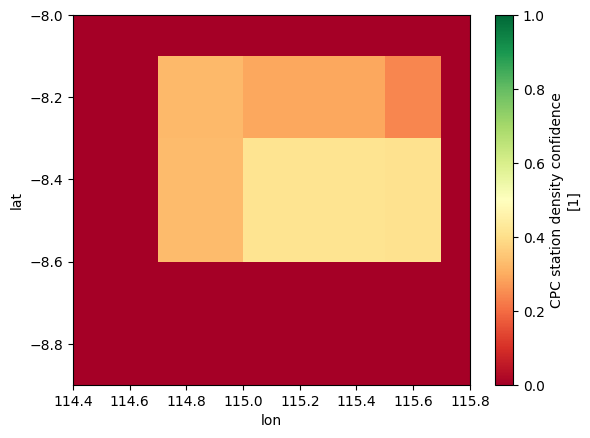

In [18]:
from src import config

confidence_mask = None  # Default: no spatial modulation (uniform blend_alpha)

if (config.USE_CONFIDENCE_MASK
    and config.STATION_FILE
    and os.path.isfile(config.STATION_FILE)):
    from src.station_density import get_or_create_confidence_mask

    logging.info("Station density confidence mask: ENABLED")
    logging.info("Station file: %s", config.STATION_FILE)

    # Use LSEQM grid coordinates as the target working grid
    confidence_mask = get_or_create_confidence_mask(
        station_file=config.STATION_FILE,
        confidence_mask_file=config.CONFIDENCE_MASK_FILE,
        target_lat=lseqm_result.lat.values,
        target_lon=lseqm_result.lon.values,
        cpc_resolution=config.DENSITY_CPC_RESOLUTION,
        smoothing_sigma=config.DENSITY_SMOOTHING_SIGMA,
        saturation_count=config.DENSITY_SATURATION_COUNT,
        lat_range=config.DENSITY_LAT_RANGE,
        lon_range=config.DENSITY_LON_RANGE,
    )
    logging.info("Confidence mask shape: %s", confidence_mask.shape)
    logging.info("Confidence range: [%.3f, %.3f]",
                 float(confidence_mask.min()), float(confidence_mask.max()))

    # Quick visualization
    confidence_mask.plot(cmap='RdYlGn', vmin=0, vmax=1)
else:
    # Explain why the confidence mask is disabled
    if not config.USE_CONFIDENCE_MASK:
        logging.info("Station density confidence mask: DISABLED (use_confidence_mask: false in config.yml)")
        logging.info("  To enable: set 'use_confidence_mask: true' in the station_density section")
    elif not config.STATION_FILE:
        logging.info("Station density confidence mask: DISABLED (no station_file configured)")
    else:
        logging.info("Station density confidence mask: DISABLED (station file not found: %s)",
                     config.STATION_FILE)
    logging.info("Using uniform blend_alpha=%.2f everywhere", config.DL_BLEND_ALPHA)

### Step 10: Apply DL Refinement and Save

Finally, we apply the trained CNN to refine extreme pixels in the LSEQM result. The DL prediction is alpha-blended with LSEQM (default: 70% LSEQM, 30% DL) so the physical-statistical backbone dominates. ([blending equation](https://bennyistanto.github.io/hybrid-bias-correction/methodology/blending.html))

In [19]:
from src.deep_learning import apply_deeplearning_model
from src.io import save_corrected_precip

logging.info("Applying DL refinement to LSEQM result...")

# Apply the trained DL model to refine extreme pixels
# If confidence_mask is available, alpha is spatially modulated by station density
corrected_precip = apply_deeplearning_model(model, lseqm_result,
                                            confidence_mask=confidence_mask)

# Ensure non-negative precipitation values
corrected_precip = corrected_precip.clip(min=0)

# Save DL-corrected precipitation
logging.info("Saving LSEQMDL corrected precipitation...")
save_corrected_precip(
    corrected_precip,
    lseqm_result,
    method_abbr="lseqmdl",
    method_full="Hybrid Deep Learning-Physical (Linear Scaling and Empirical Quantile Mapping) Approach",
    folder=config.lseqmdl_corrected_precip_path,
    dekad_str=dekad_str,
    month_str=month_str
)
logging.info("LSEQMDL bias correction completed successfully.")
print("Bias correction process finished. Please check the output directories for corrected datasets.")

2026-05-22 01:03:14,509 - INFO - Applying DL refinement to LSEQM result...
2026-05-22 01:03:14,529 - INFO - Pixel-wise threshold map computed at 80th percentile. threshold_2d shape: (9, 14)
2026-05-22 01:03:14,530 - INFO - DL blending: base alpha=0.70 (LSEQM weight), 1-alpha=0.30 (DL weight)
2026-05-22 01:03:14,533 - INFO - Confidence mask active: spatial alpha modulation enabled. Confidence range: [0.000, 0.411]
2026-05-22 01:03:42,503 - INFO - DL blending complete: 250 daily slices processed, 3,999 extreme pixels blended (alpha=0.70)
2026-05-22 01:03:42,695 - INFO - Saving LSEQMDL corrected precipitation...
2026-05-22 01:03:43,013 - INFO - File /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/corrected_lseqmdl/bali_cli_lseqmdl_corrected_imergl_month01_dekad01.nc4 already exists.
2026-05-22 01:03:43,014 - INFO - Skipping file /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/corrected_lseqmdl/bali_cli_lseqmdl_corrected_imergl_month01_dekad01.

After processing, preview a plot of the corrected precipitation to visually verify the result.

::: {.callout-tip title="What you should see"}
The corrected map for Bali should be **visibly wetter than raw IMERG-L** over the central-eastern mountains (where CPC's gauges report consistently heavier rain) and **lower than raw IMERG-L** along the southern coastal plain (where IMERG-L over-detects light rain). If the corrected map looks nearly identical to LSEQM, the DL stage may be inactive (check the confidence-mask logs in Step 9) - this is intended behaviour in Bali's gauge-sparse regions, not a bug.
:::


Corrected Precipitation Data Summary:
<xarray.DataArray (time: 250, lat: 9, lon: 14)> Size: 126kB
array([[[        nan,         nan,         nan, ...,   4.9697576,
           6.3031607,         nan],
        [        nan,         nan,         nan, ...,   4.1157603,
           6.763117 ,         nan],
        [        nan,         nan,         nan, ...,   0.       ,
                 nan,         nan],
        ...,
        [  0.       ,   0.       ,   0.       , ...,   0.       ,
           0.       ,         nan],
        [  0.       ,   0.       ,   0.       , ...,   0.       ,
                 nan,         nan],
        [  0.       ,   0.       ,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,   0.       ,
           0.       ,         nan],
        [        nan,         nan,         nan, ...,   0.       ,
           0.       ,         nan],
        [        nan,         nan,         nan, ...,   0.       ,
     

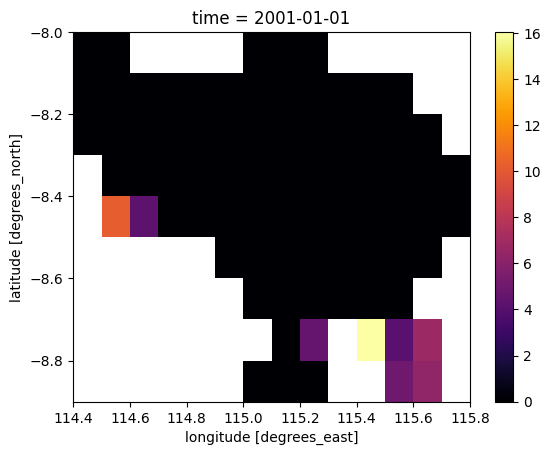

In [20]:
# Preview final bias-corrected data
print("Corrected Precipitation Data Summary:")
print(corrected_precip)
corrected_precip.isel(time=0).plot(cmap='inferno')


---


## What changed because of this notebook?

| Stage | Output file (pointed at by `config.*_corrected_precip_path`) | What it fixes |
|---|---|---|
| Raw IMERG-L | (input - not modified) | (baseline) |
| LS | `corrected_ls/{prefix}_ls_corrected_imergl_month{MM}_dekad{DD}.nc4` | Long-term mean per dekad |
| LSEQM | `corrected_lseqm/...` | LS + the full distribution shape (Gamma body) + extremes (GPD tail) |
| LSEQM+DL | `corrected_lseqmdl/...` | LSEQM + a CNN refinement, alpha-blended where station density supports it |

The three NetCDFs are the inputs for nb03 (metrics), nb04 (QA), nb05 (station validation), and nb06 (figures).

## Summary

---

## Batch Run - All Months and Dekads

Run this cell to execute the **full LSEQMDL bias correction pipeline**
(LS → LSEQM → DL train → DL apply → save) for every month×dekad combination
(12 months × 3 dekads = 36 periods).

Existing DL models are reloaded silently without prompting. Periods that
fail are skipped with a warning so the batch can continue.

**Prerequisites - run these cells first (skip Steps 2 and 4–10):**

| Cell | Purpose |
|------|---------|
| Step 1 | Environment setup, imports, `config` |
| Step 3 | Load IMERG + CPC datasets (`imerg_ds`, `cpc_ds`) |
| Step 5 | Align CPC to IMERG grid (`cpc_ds_aligned`) |

In [ ]:
"""
Batch run - full LSEQMDL pipeline for all 36 month×dekad periods.

Requires: imerg_ds, cpc_ds_aligned, cpc_ds_native (from Steps 3 + 5).
"""
from src.bias_correction import run_correction_pipeline

n_done = 0
n_skip = 0

for _m in range(1, 13):
    for _d in [1, 2, 3]:
        tag = f"month {_m:02d} dekad {_d}"
        print(f"\n{'='*60}")
        print(f"▸ {tag}")
        print(f"{'='*60}")
        try:
            out_path = run_correction_pipeline(
                imerg_ds, cpc_ds_aligned, _m, _d,
                cpc_native_ds=cpc_ds_native
            )
            n_done += 1
            print(f"✓ {tag} — saved: {out_path}")
        except Exception as e:
            n_skip += 1
            print(f"✗ {tag} — FAILED: {e}")

print(f"\n{'='*60}")
print(f"Batch complete: {n_done} periods done, {n_skip} skipped.")
print(f"{'='*60}")


▸ month 01 dekad 1
2026-05-20 06:43:09,754 - INFO - Pipeline [01 d1]: Running LSEQM...
2026-05-20 06:43:09,762 - INFO - Aligning IMERG and CPC datasets...
2026-05-20 06:43:09,793 - INFO - After alignment: IMERG has 9131 time steps, CPC has 9131 time steps
2026-05-20 06:43:09,793 - INFO - Creating time-based masks...
2026-05-20 06:43:09,804 - INFO - Applying time masks...
2026-05-20 06:43:09,828 - INFO - IMERG dekad data shape: (250, 9, 14)
2026-05-20 06:43:09,829 - INFO - CPC dekad data shape: (250, 9, 14)
2026-05-20 06:43:09,832 - INFO - Using native-resolution CPC parameter fitting (BCSD principle)...
2026-05-20 06:43:09,866 - INFO - CPC native dekad data: (250, 4, 6) (lat -9.25–-7.75, lon 113.75–116.25)
2026-05-20 06:43:13,338 - INFO -   Native CPC fitting: row 4/4 (100%) | 24 fitted, 0 skipped | elapsed 3s, ETA 0s
2026-05-20 06:43:13,339 - INFO - Fitted CPC params on native grid: 24/24 cells
2026-05-20 06:43:13,382 - INFO - Interpolated CPC params to IMERG grid: 126/126 valid pixe

2026-05-20 06:43:13,733 - INFO - Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 9, 14, 32)      │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 3, 64)       │             0 │
├──────────────────────

2026-05-20 06:43:40,299 - INFO - Model: "sequential_1"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 9, 14, 32)      │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 3, 64)       │             0 │
├────────────────────

2026-05-20 06:44:05,322 - INFO - Model: "sequential_2"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 9, 14, 32)      │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 3, 64)       │             0 │
├────────────────────

2026-05-20 06:44:32,339 - INFO - Model: "sequential_3"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 9, 14, 32)      │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 4, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 3, 64)       │             0 │
├────────────────────

...

2026-05-20 06:57:07,519 - INFO - Model: "sequential_31"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_62 (Conv2D)              │ (None, 9, 14, 32)      │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_62 (MaxPooling2D) │ (None, 4, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_93 (Dropout)            │ (None, 4, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 4, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_63 (MaxPooling2D) │ (None, 2, 3, 64)       │             0 │
├───────────────────

2026-05-20 06:57:31,756 - INFO - Model: "sequential_32"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_64 (Conv2D)              │ (None, 9, 14, 32)      │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_64 (MaxPooling2D) │ (None, 4, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_96 (Dropout)            │ (None, 4, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 4, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_65 (MaxPooling2D) │ (None, 2, 3, 64)       │             0 │
├───────────────────

2026-05-20 06:58:02,110 - INFO - Model: "sequential_33"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_66 (Conv2D)              │ (None, 9, 14, 32)      │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_66 (MaxPooling2D) │ (None, 4, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_99 (Dropout)            │ (None, 4, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 4, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_67 (MaxPooling2D) │ (None, 2, 3, 64)       │             0 │
├───────────────────

2026-05-20 06:58:31,379 - INFO - Model: "sequential_34"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_68 (Conv2D)              │ (None, 9, 14, 32)      │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_68 (MaxPooling2D) │ (None, 4, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_102 (Dropout)           │ (None, 4, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (None, 4, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_69 (MaxPooling2D) │ (None, 2, 3, 64)       │             0 │
├───────────────────

2026-05-20 06:58:58,541 - INFO - Model: "sequential_35"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_70 (Conv2D)              │ (None, 9, 14, 32)      │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_70 (MaxPooling2D) │ (None, 4, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_105 (Dropout)           │ (None, 4, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 4, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_71 (MaxPooling2D) │ (None, 2, 3, 64)       │             0 │
├───────────────────

---

## End of Code